In [1]:
import os
import sys
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Xác định đường dẫn thư mục gốc (Project Root)
# Vì notebook nằm trong thư mục 'notebooks/', chúng ta cần lấy thư mục cha của nó.
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, ".."))

# 2. Thêm project_root vào sys.path để có thể import các module từ thư mục 'src/'
if project_root not in sys.path:
    sys.path.append(project_root)
    sys.path.append(os.path.join(project_root, "src"))

# 3. Load file config.yaml
config_path = os.path.join(project_root, "config.yaml")
with open(config_path, 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

print(f"✅ Project Root: {project_root}")
print(f"✅ Config loaded. Paths check:")
print(f"   - CafeF Path: {config['paths']['processed_cafef']}")
print(f"   - Vietstock Path: {config['paths']['processed_vietstock']}")

✅ Project Root: d:\Desktop\3T_Test\datacore-board-assessment
✅ Config loaded. Paths check:
   - CafeF Path: data/processed/cafef_processed.parquet
   - Vietstock Path: data/processed/vietstock_processed.parquet


In [2]:
# 4. Tạo đường dẫn tuyệt đối đến file Parquet
path_cf = os.path.join(project_root, config['paths']['processed_cafef'])
path_vs = os.path.join(project_root, config['paths']['processed_vietstock'])

# 5. Đọc dữ liệu
try:
    df_cf = pd.read_parquet(path_cf)
    df_vs = pd.read_parquet(path_vs)
    
    print(f"📊 CafeF Data: {df_cf.shape[0]} records, {df_cf.shape[1]} columns")
    print(f"📊 Vietstock Data: {df_vs.shape[0]} records, {df_vs.shape[1]} columns")
except FileNotFoundError as e:
    print(f"❌ Lỗi: Không tìm thấy file dữ liệu. Hãy đảm bảo bạn đã chạy các script scrape trước đó.\n chi tiết: {e}")

# Hiển thị mẫu để kiểm tra schema
display(df_cf.head(3))
display(df_vs.head(3))

📊 CafeF Data: 1140 records, 6 columns
📊 Vietstock Data: 828 records, 6 columns


,ticker,exchange,person_name,role,source,scraped_at
0,VIN,UPCOM,Ông Nguyễn Minh Huy,Chủ tịch HĐQT,cafef,2026-03-04T01:24:47.481456
1,VIN,UPCOM,Ông Nguyễn Thanh Tòng,Thành viên HĐQT,cafef,2026-03-04T01:24:47.481456
2,VIN,UPCOM,Bà Lê Thị Thu Hiền,Thành viên HĐQT,cafef,2026-03-04T01:24:47.481456


,ticker,exchange,person_name,role,source,scraped_at
0,VIN,UPCOM,Ông Phạm Công Dũng,CTHĐQT,vietstock,2026-03-04T01:31:00.610104
1,VIN,UPCOM,Ông Nguyễn Duy Dũng,TVHĐQT,vietstock,2026-03-04T01:31:00.610104
2,VIN,UPCOM,Ông Hà Minh Huấn,TGĐ/TVHĐQT,vietstock,2026-03-04T01:31:00.610104


📊 Thống kê số lượng bản ghi theo sàn:
          CafeF  Vietstock
exchange                  
HOSE      675.0        492
HNX       451.0        304
UPCOM      14.0          9
DEFAULT     0.0         23


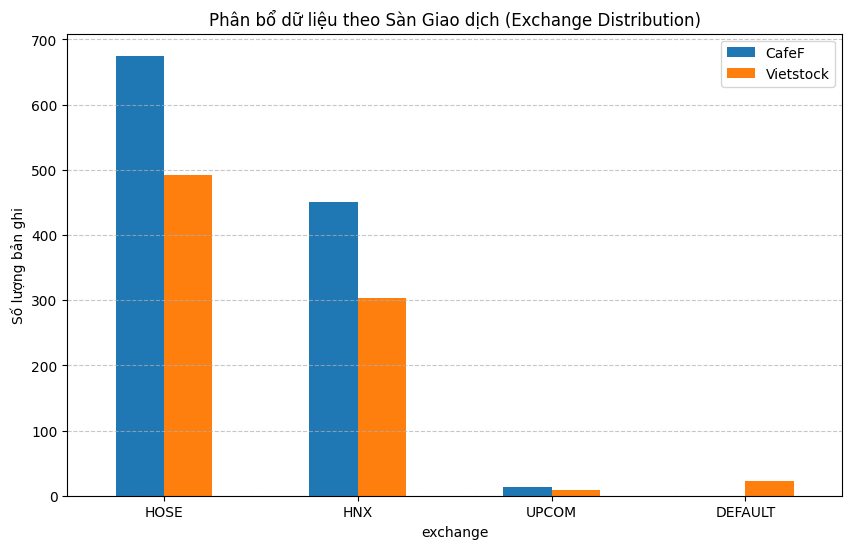

In [4]:
# 1. Thống kê số lượng theo sàn (Exchange)
exchange_counts = pd.concat([
    df_cf['exchange'].value_counts().rename('CafeF'),
    df_vs['exchange'].value_counts().rename('Vietstock')
], axis=1).fillna(0)

print("📊 Thống kê số lượng bản ghi theo sàn:")
print(exchange_counts)

# 2. Vẽ biểu đồ so sánh
plt.figure(figsize=(10, 6))
exchange_counts.plot(kind='bar', ax=plt.gca())
plt.title('Phân bổ dữ liệu theo Sàn Giao dịch (Exchange Distribution)')
plt.ylabel('Số lượng bản ghi')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

C:\Users\asus\AppData\Local\Temp\ipykernel_31120\1486772001.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_diff, x='ticker', y='diff', palette='viridis')


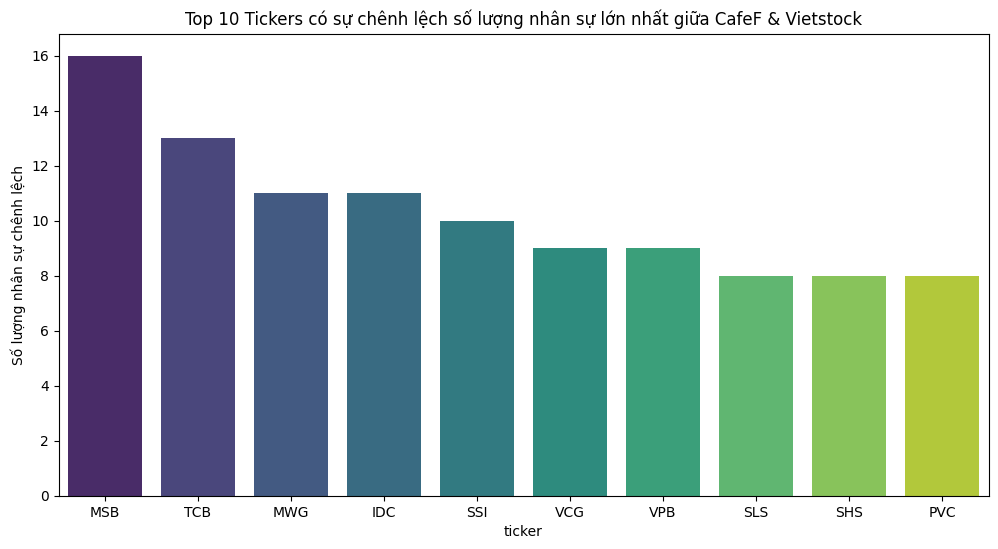

Top mã cần lưu ý (có độ lệch cao):
   ticker  count_cf  count_vs  diff
26    MSB        30        14    16
46    TCB        29        16    13
28    MWG        20         9    11
19    IDC        18         7    11
43    SSI        19         9    10
51    VCG        20        11     9
58    VPB        30        21     9
42    SLS        17         9     8
41    SHS        14         6     8
37    PVC        17         9     8


In [3]:
# Đếm số lượng nhân sự theo từng Ticker ở 2 nguồn
count_cf = df_cf.groupby('ticker')['person_name'].count().reset_index(name='count_cf')
count_vs = df_vs.groupby('ticker')['person_name'].count().reset_index(name='count_vs')

# Merge 2 bảng đếm để so sánh
comparison = pd.merge(count_cf, count_vs, on='ticker', how='outer').fillna(0)
comparison['diff'] = abs(comparison['count_cf'] - comparison['count_vs'])

# Sắp xếp theo độ lệch giảm dần
top_diff = comparison.sort_values(by='diff', ascending=False).head(10)

# Trực quan hóa
plt.figure(figsize=(12, 6))
sns.barplot(data=top_diff, x='ticker', y='diff', palette='viridis')
plt.title('Top 10 Tickers có sự chênh lệch số lượng nhân sự lớn nhất giữa CafeF & Vietstock')
plt.ylabel('Số lượng nhân sự chênh lệch')
plt.show()

print("Top mã cần lưu ý (có độ lệch cao):")
print(top_diff[['ticker', 'count_cf', 'count_vs', 'diff']])

In [6]:
from collections import Counter
import re

def get_top_roles(df, column_name, top_n=20):
    # Tách các chức danh kép (ngăn cách bởi dấu / hoặc dấu ,) và đếm
    all_roles = []
    for roles in df[column_name].dropna():
        # Tách và làm sạch khoảng trắng
        split_roles = [r.strip() for r in re.split(r'[/,;]', str(roles))]
        all_roles.extend(split_roles)
    return Counter(all_roles).most_common(top_n)

print("🔝 Top 15 chức danh phổ biến nhất trên CafeF:")
for role, count in get_top_roles(df_cf, 'role', 15):
    print(f"- {role}: {count}")

print("\n🔝 Top 15 chức danh phổ biến nhất trên Vietstock:")
for role, count in get_top_roles(df_vs, 'role', 15):
    print(f"- {role}: {count}")

🔝 Top 15 chức danh phổ biến nhất trên CafeF:
- Phó Tổng GĐ: 179
- Thành viên HĐQT: 170
- Thành viên BKS: 122
- Chủ tịch HĐQT: 55
- Kế toán trưởng: 55
- Thành viên HĐQT độc lập: 53
- Tổng Giám đốc: 51
- Trưởng BKS: 46
- Phụ trách quản trị: 43
- Thành Viên HĐQT: 43
- Phó Chủ tịch HĐQT: 34
- Công bố thông tin: 27
- Phó Giám đốc: 22
- Người được ủy quyền công bố thông tin: 21
- Thư ký công ty: 14

🔝 Top 15 chức danh phổ biến nhất trên Vietstock:
- TVHĐQT: 262
- Phó TGĐ: 184
- Thành viên BKS: 103
- CTHĐQT: 56
- KTT: 54
- TGĐ: 50
- ***: 47
- Trưởng BKS: 44
- Phó CTHĐQT: 41
- TV Ủy ban Kiểm toán: 16
- GĐ Tài chính: 15
- Chủ tịch Ủy ban Kiểm toán: 11
- Phó GĐ: 10
- Thành viên ban điều hành: 7
- GĐ Điều hành: 6


In [8]:
# Tính tỷ lệ phần trăm Null cho mỗi cột
null_cf = (df_cf.isnull().sum() / len(df_cf)) * 100
null_vs = (df_vs.isnull().sum() / len(df_vs)) * 100

null_report = pd.DataFrame({
    'CafeF Null %': null_cf,
    'Vietstock Null %': null_vs
}).fillna(0)

print("📝 Báo cáo dữ liệu trống (Null Rates):")
display(null_report)


📝 Báo cáo dữ liệu trống (Null Rates):


,CafeF Null %,Vietstock Null %
ticker,0.0,0.0
exchange,0.0,0.0
person_name,0.0,0.0
role,0.0,0.0
source,0.0,0.0
scraped_at,0.0,0.0
